# Cluster Motifs detection

In [2]:
here::i_am("atac/archR/differential/cells/differential_clusters.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))
suppressPackageStartupMessages(library(batchelor))
suppressPackageStartupMessages(library(ArchR))

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 21

# Multi core using future - built in to seurat
plan("multicore", workers = 16)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
      

In [3]:
args = list()
args$archr_directory = file.path(io$basedir, 'processed/atac/archR')

# outdir
args$outdir_clusters = file.path(io$basedir, 'results/rna_atac/dimensionality_reduction/')
dir.create(args$outdir_clusters, recursive=TRUE, showWarnings =FALSE)

args$outdir_markers = file.path(io$basedir, 'results/rna_atac/markers/')
dir.create(args$outdir_markers, recursive=TRUE, showWarnings =FALSE)

### Load data

In [4]:
seurat = readRDS(sprintf('%s/seurat_object.rds', args$outdir_clusters))

In [5]:
meta = as.data.table(seurat@meta.data, keep.rownames=T) %>% setnames('rn', 'cell')

In [6]:
ArchRProject <- loadArchRProject(args$archr_directory)[meta$cell]

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [7]:
ArchRProject <- addCellColData(ArchRProj = ArchRProject, 
                                    data = as.numeric(meta$seurat_clusters),
                                    cells = meta$cell,
                                    name = "seurat_clusters",
                                    force=TRUE)

In [13]:
addArchRThreads(16)

Setting default number of Parallel threads to 16.



In [65]:
out <- getMarkerFeatures( # suppressMessages(
          ArchRProj = ArchRProject, #.filt, 
          useMatrix = "PeakMatrix",
          groupBy = "seurat_clusters",
          testMethod = "wilcoxon", #"binomial",
          binarize=FALSE,
          bias = c("TSSEnrichment", "log10(nFrags)"),
          verbose=TRUE
        )

ArchR logging to : ArchRLogs/ArchR-getMarkerFeatures-c8e6726ad7228-Date-2023-02-22_Time-16-45-28.log
If there is an issue, please report to github with logFile!

MatrixClass = Sparse.Integer.Matrix

2023-02-22 16:45:34 : Matching Known Biases, 0.006 mins elapsed.

###########
2023-02-22 16:49:44 : Completed Pairwise Tests, 4.176 mins elapsed.
###########

ArchR logging successful to : ArchRLogs/ArchR-getMarkerFeatures-c8e6726ad7228-Date-2023-02-22_Time-16-45-28.log



In [48]:
ArchRProject@peakAnnotation

List of length 2
names(2): Motif_cisbp Motif_JASPAR2020

In [66]:
enrichMotifs <- suppressMessages(peakAnnoEnrichment(
    seMarker = out,
    ArchRProj = ArchRProject,
    peakAnnotation = "Motif_cisbp",
    cutOff = "FDR <= 0.1 & Log2FC >= 0.5"
  ))

In [67]:
enrichMotifs

class: SummarizedExperiment 
dim: 884 22 
metadata(0):
assays(10): mlog10Padj mlog10p ... CompareFrequency feature
rownames(884): Tcfap2a_1 Tcfap2b_2 ... Smad5_883 Smad9_884
rowData names(0):
colnames(22): 1 2 ... 21 22
colData names(0):

In [68]:
plot_enr_heatmap = function(enrichMotifs, ntop=25) {
    heatmapEM <- plotEnrichHeatmap(enrichMotifs, n = ntop, returnMatrix = TRUE)

    enriched.dt = melt(as.data.table(heatmapEM, keep.rownames=T) %>% setnames('rn', 'TF'), id.vars = c("TF")) %>%
        .[order(-value)] 
    keep_tfs = enriched.dt[, head(.SD, ntop),  by=variable]$TF
    enriched.dt = enriched.dt[TF %in% keep_tfs] %>% .[order( -value)] %>% 
        .[,TF:=strsplit(TF, '_') %>% map_chr(1)] %>%
         .[,TF:=factor(TF, levels=unique(TF))] %>%
        .[,variable:=factor(variable, levels=0:length(unique(variable)))]
    
    p = ggplot(enriched.dt, aes(TF, variable, fill=value)) + 
    geom_tile(col='black') + 
    viridis::scale_fill_viridis(name='Norm. Enrichment -log10(P-adj) [0-max]') + 
    theme_void() + theme(text=element_text(size=15), 
                         axis.text.x=element_text(angle=-90,hjust=0,vjust=0.5, size=15), 
                         axis.text.y=element_text(hjust=0),
                        legend.position='bottom')
    return(p)
}

ArchR logging to : ArchRLogs/ArchR-plotEnrichHeatmap-c8e6776945179-Date-2023-02-22_Time-16-50-11.log
If there is an issue, please report to github with logFile!



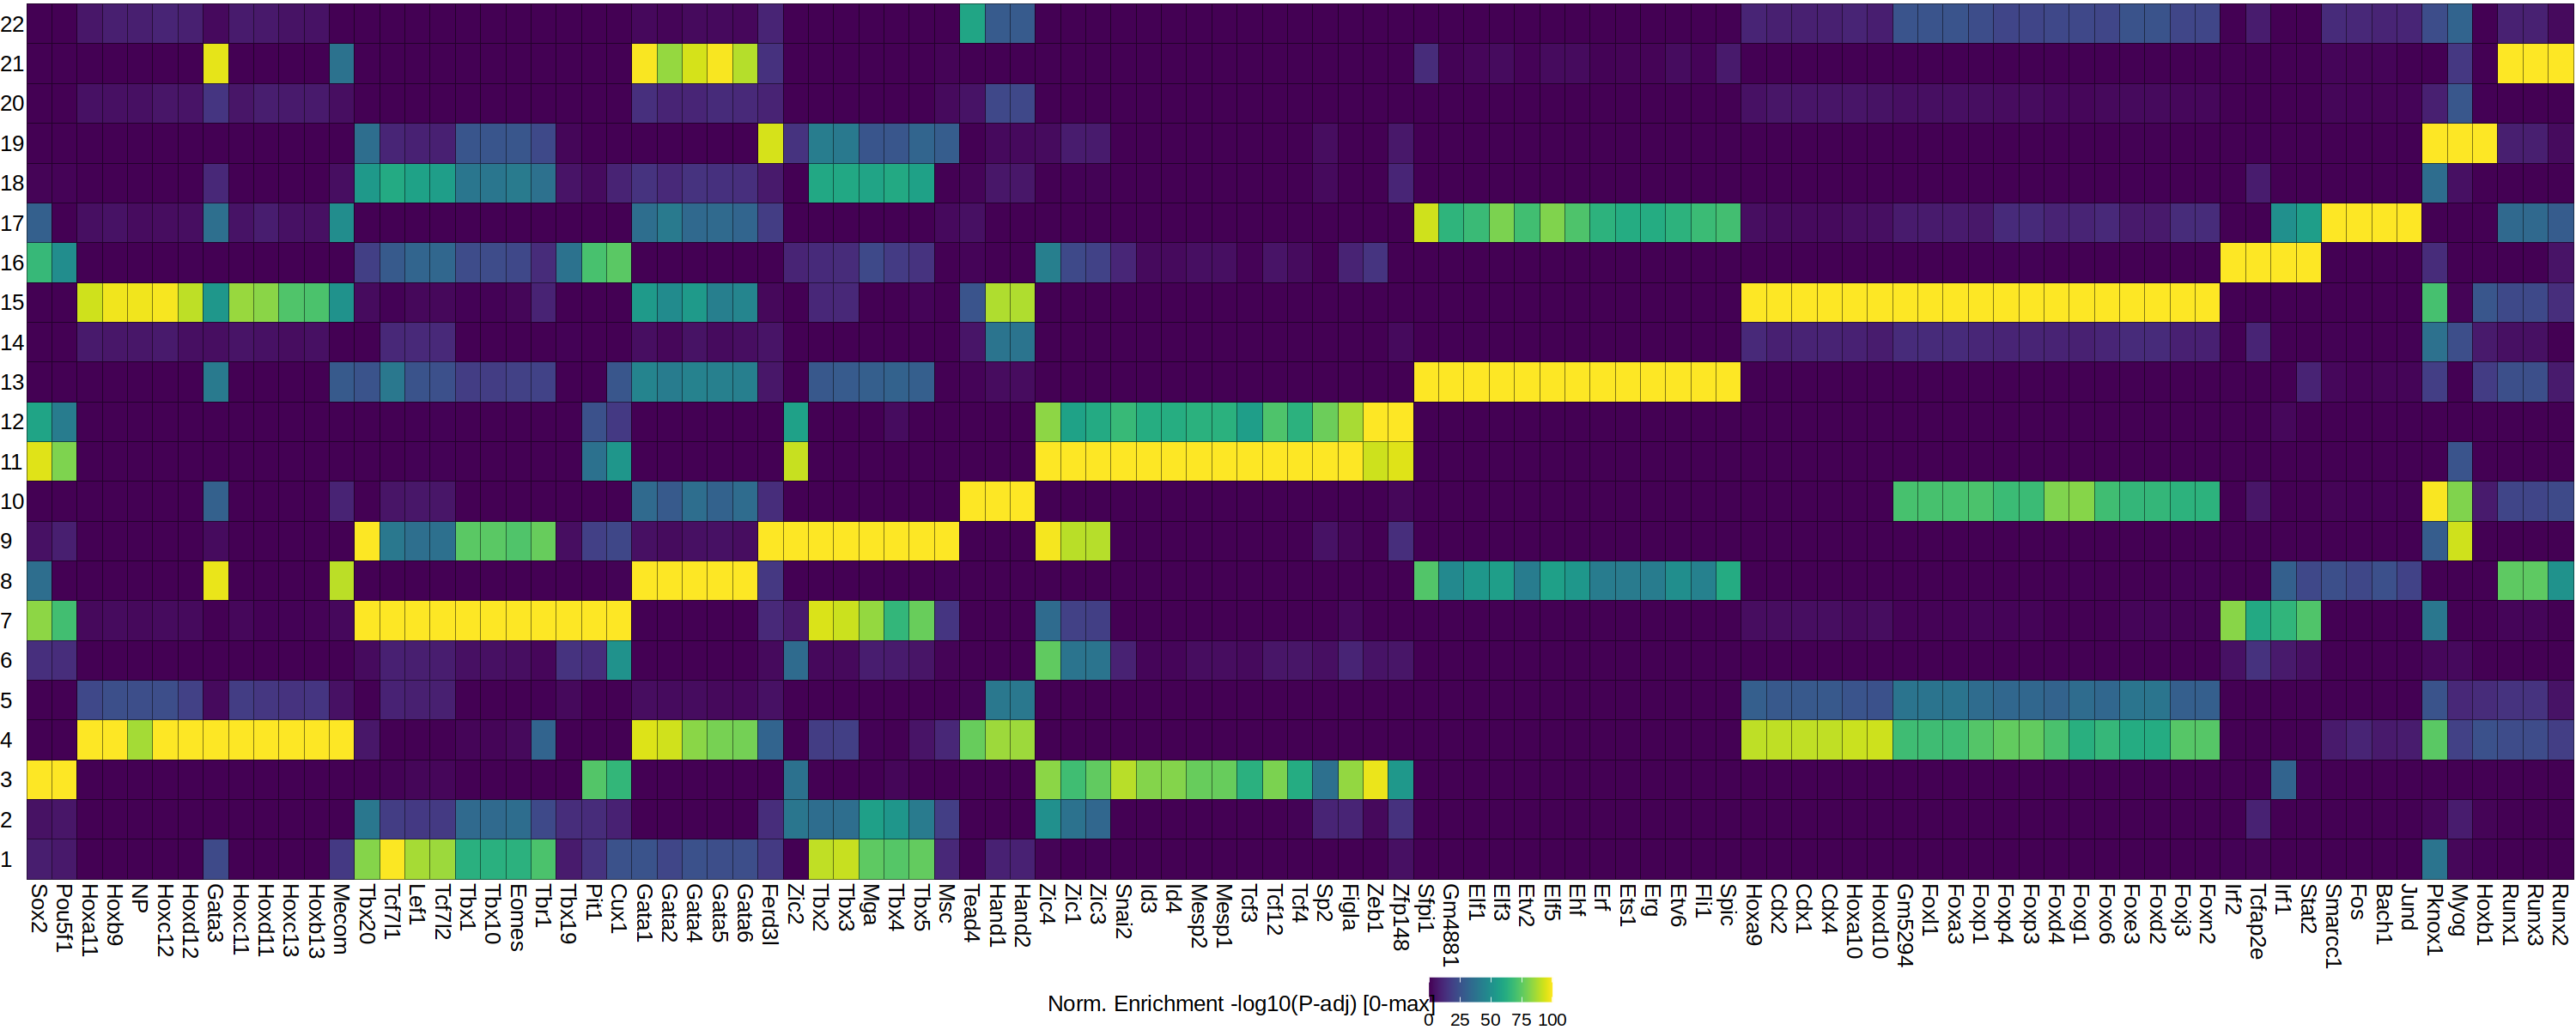

In [69]:
options(repr.plot.width=25, repr.plot.height=10)
plot_enr_heatmap(enrichMotifs, ntop = 15)

In [ ]:
plot_enr_heatmap(enrichMotifs, ntop = 15) +
    

In [14]:
out <- getMarkerFeatures( # suppressMessages(
          ArchRProj = ArchRProject, #.filt, 
          useMatrix = "PeakMatrix",
          groupBy = "seurat_clusters",
          testMethod = "binomial", #"binomial",
          binarize=TRUE,
          bias = c("TSSEnrichment", "log10(nFrags)"),
          verbose=TRUE
        )

ArchR logging to : ArchRLogs/ArchR-getMarkerFeatures-c8e6716fb683d-Date-2023-02-22_Time-16-10-52.log
If there is an issue, please report to github with logFile!

MatrixClass = Sparse.Integer.Matrix

2023-02-22 16:10:57 : Matching Known Biases, 0.005 mins elapsed.

###########
2023-02-22 16:14:17 : Completed Pairwise Tests, 3.333 mins elapsed.
###########

ArchR logging successful to : ArchRLogs/ArchR-getMarkerFeatures-c8e6716fb683d-Date-2023-02-22_Time-16-10-52.log



ArchR logging to : ArchRLogs/ArchR-plotEnrichHeatmap-c8e676910ed9c-Date-2023-02-22_Time-16-42-14.log
If there is an issue, please report to github with logFile!



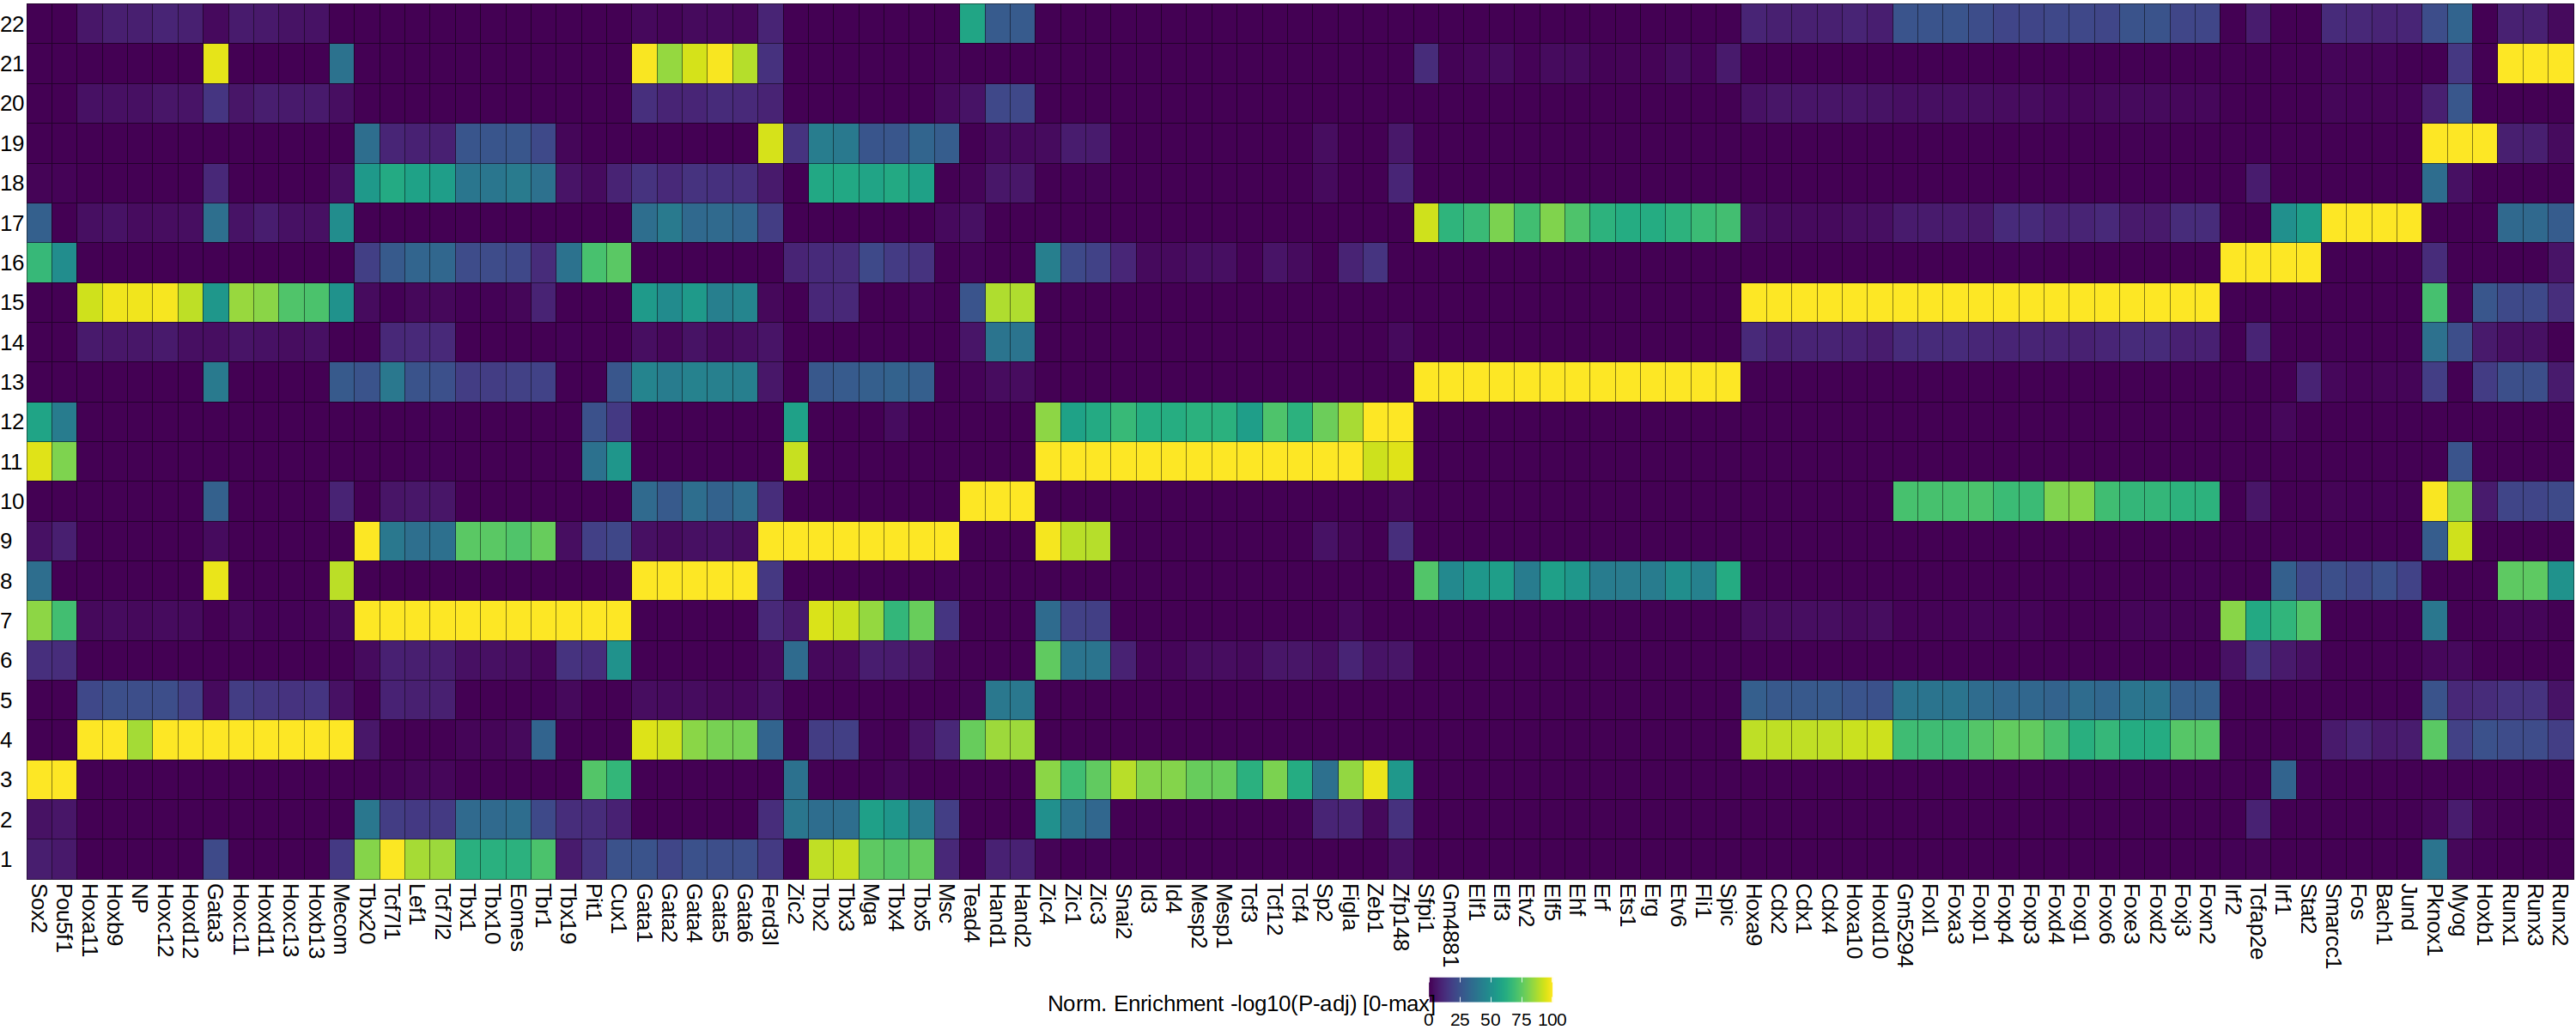

In [64]:
enrichMotifs <- suppressMessages(peakAnnoEnrichment(
    seMarker = out,
    ArchRProj = ArchRProject,
    peakAnnotation = "Motif_cisbp",
    cutOff = "FDR <= 0.1 & Log2FC >= 0.5"
  ))

options(repr.plot.width=25, repr.plot.height=10)
plot_enr_heatmap(enrichMotifs, ntop = 15) 

ArchR logging to : ArchRLogs/ArchR-plotEnrichHeatmap-c8e67859b86d-Date-2023-02-22_Time-17-00-04.log
If there is an issue, please report to github with logFile!

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


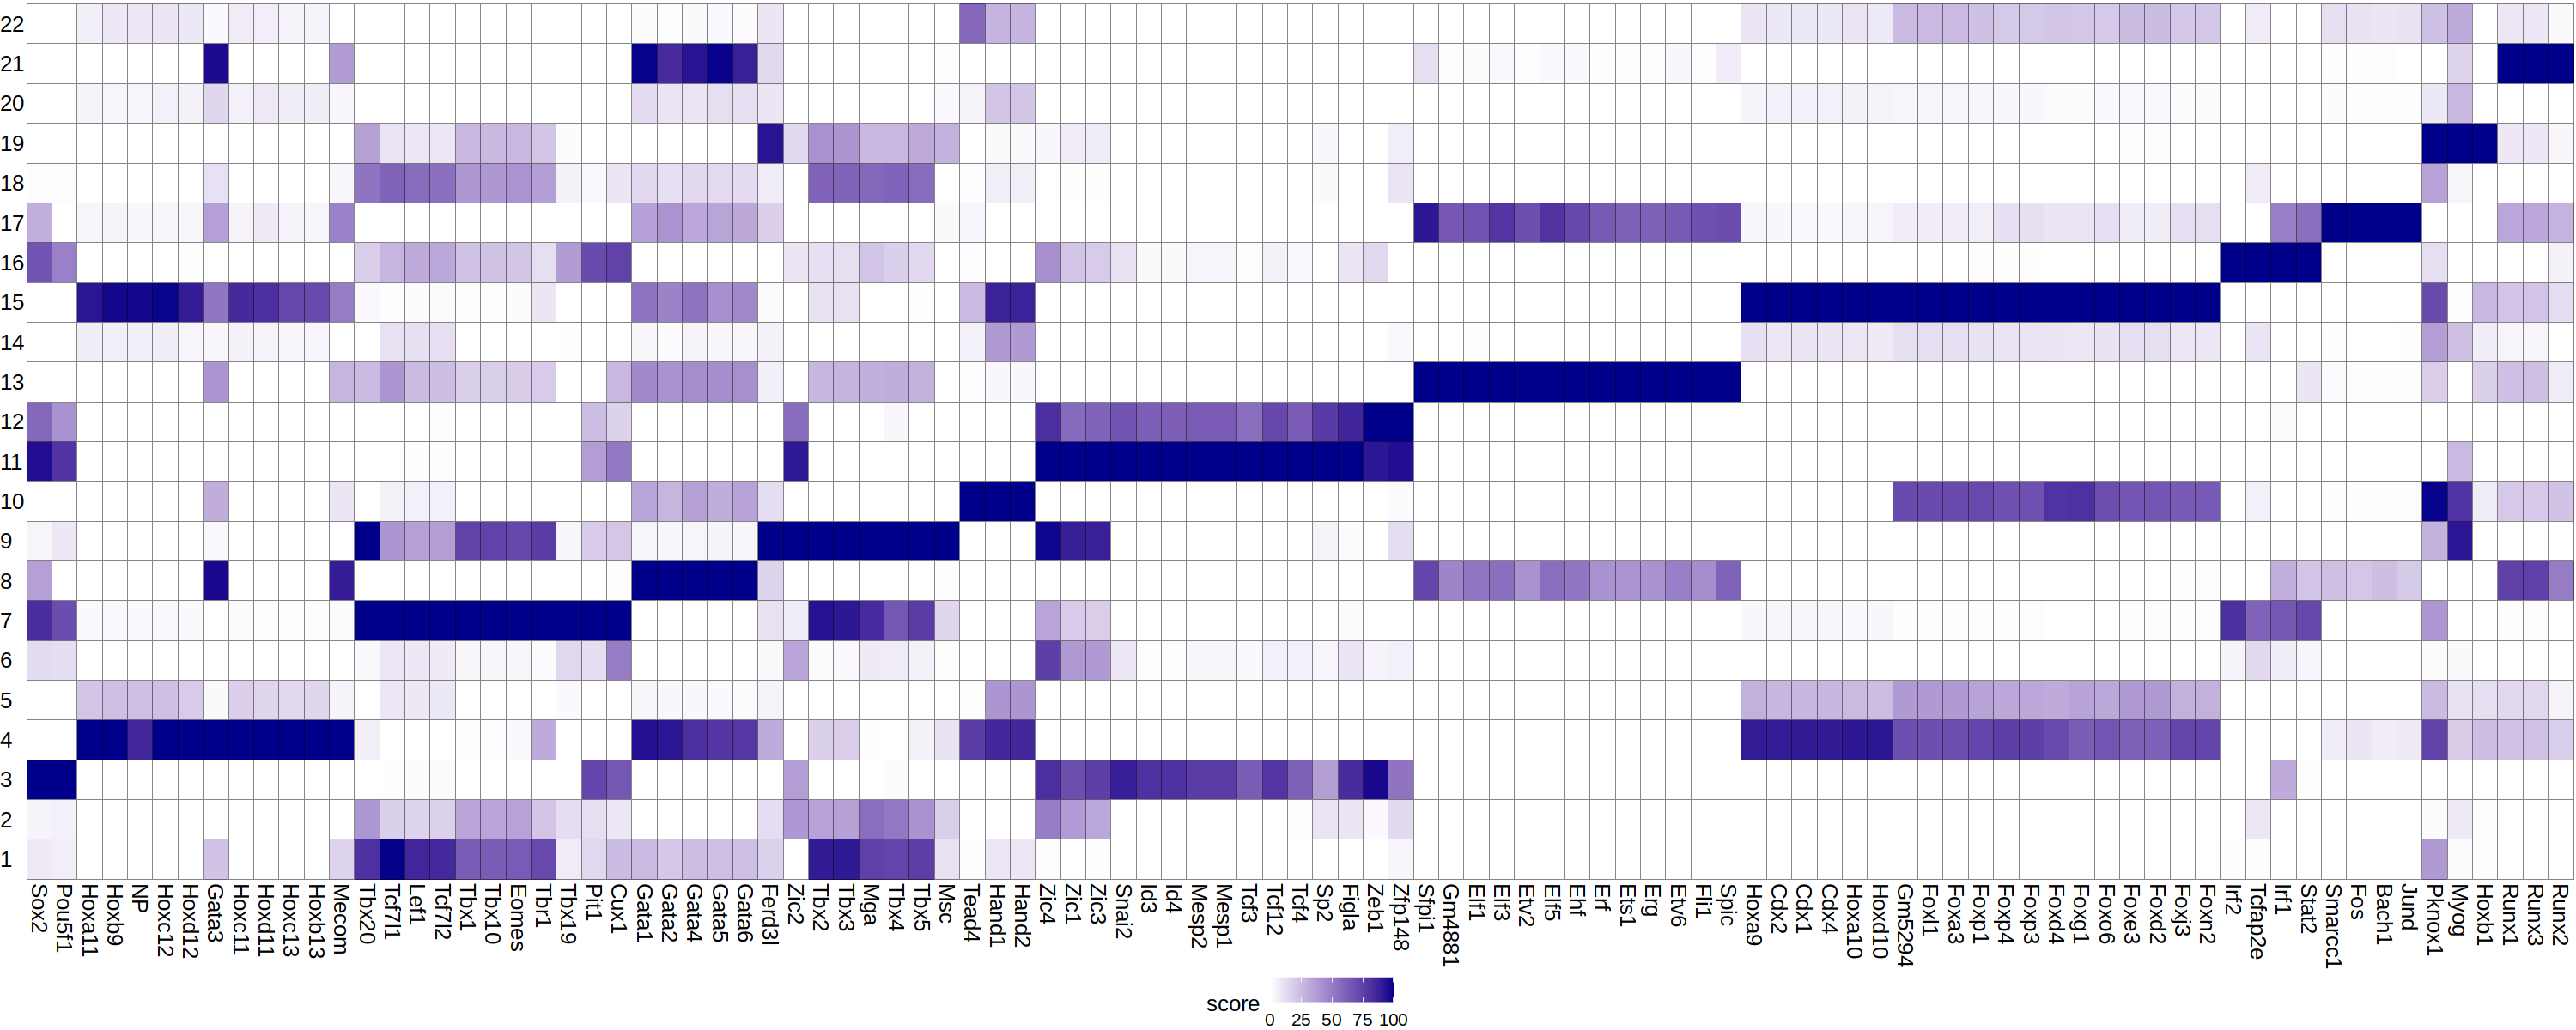

In [73]:
plot_enr_heatmap(enrichMotifs, ntop = 15) + 
        scale_fill_gradient(low='white', high='darkblue', name='score')

ArchR logging to : ArchRLogs/ArchR-plotEnrichHeatmap-c8e6751966c79-Date-2023-02-22_Time-18-19-46.log
If there is an issue, please report to github with logFile!

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


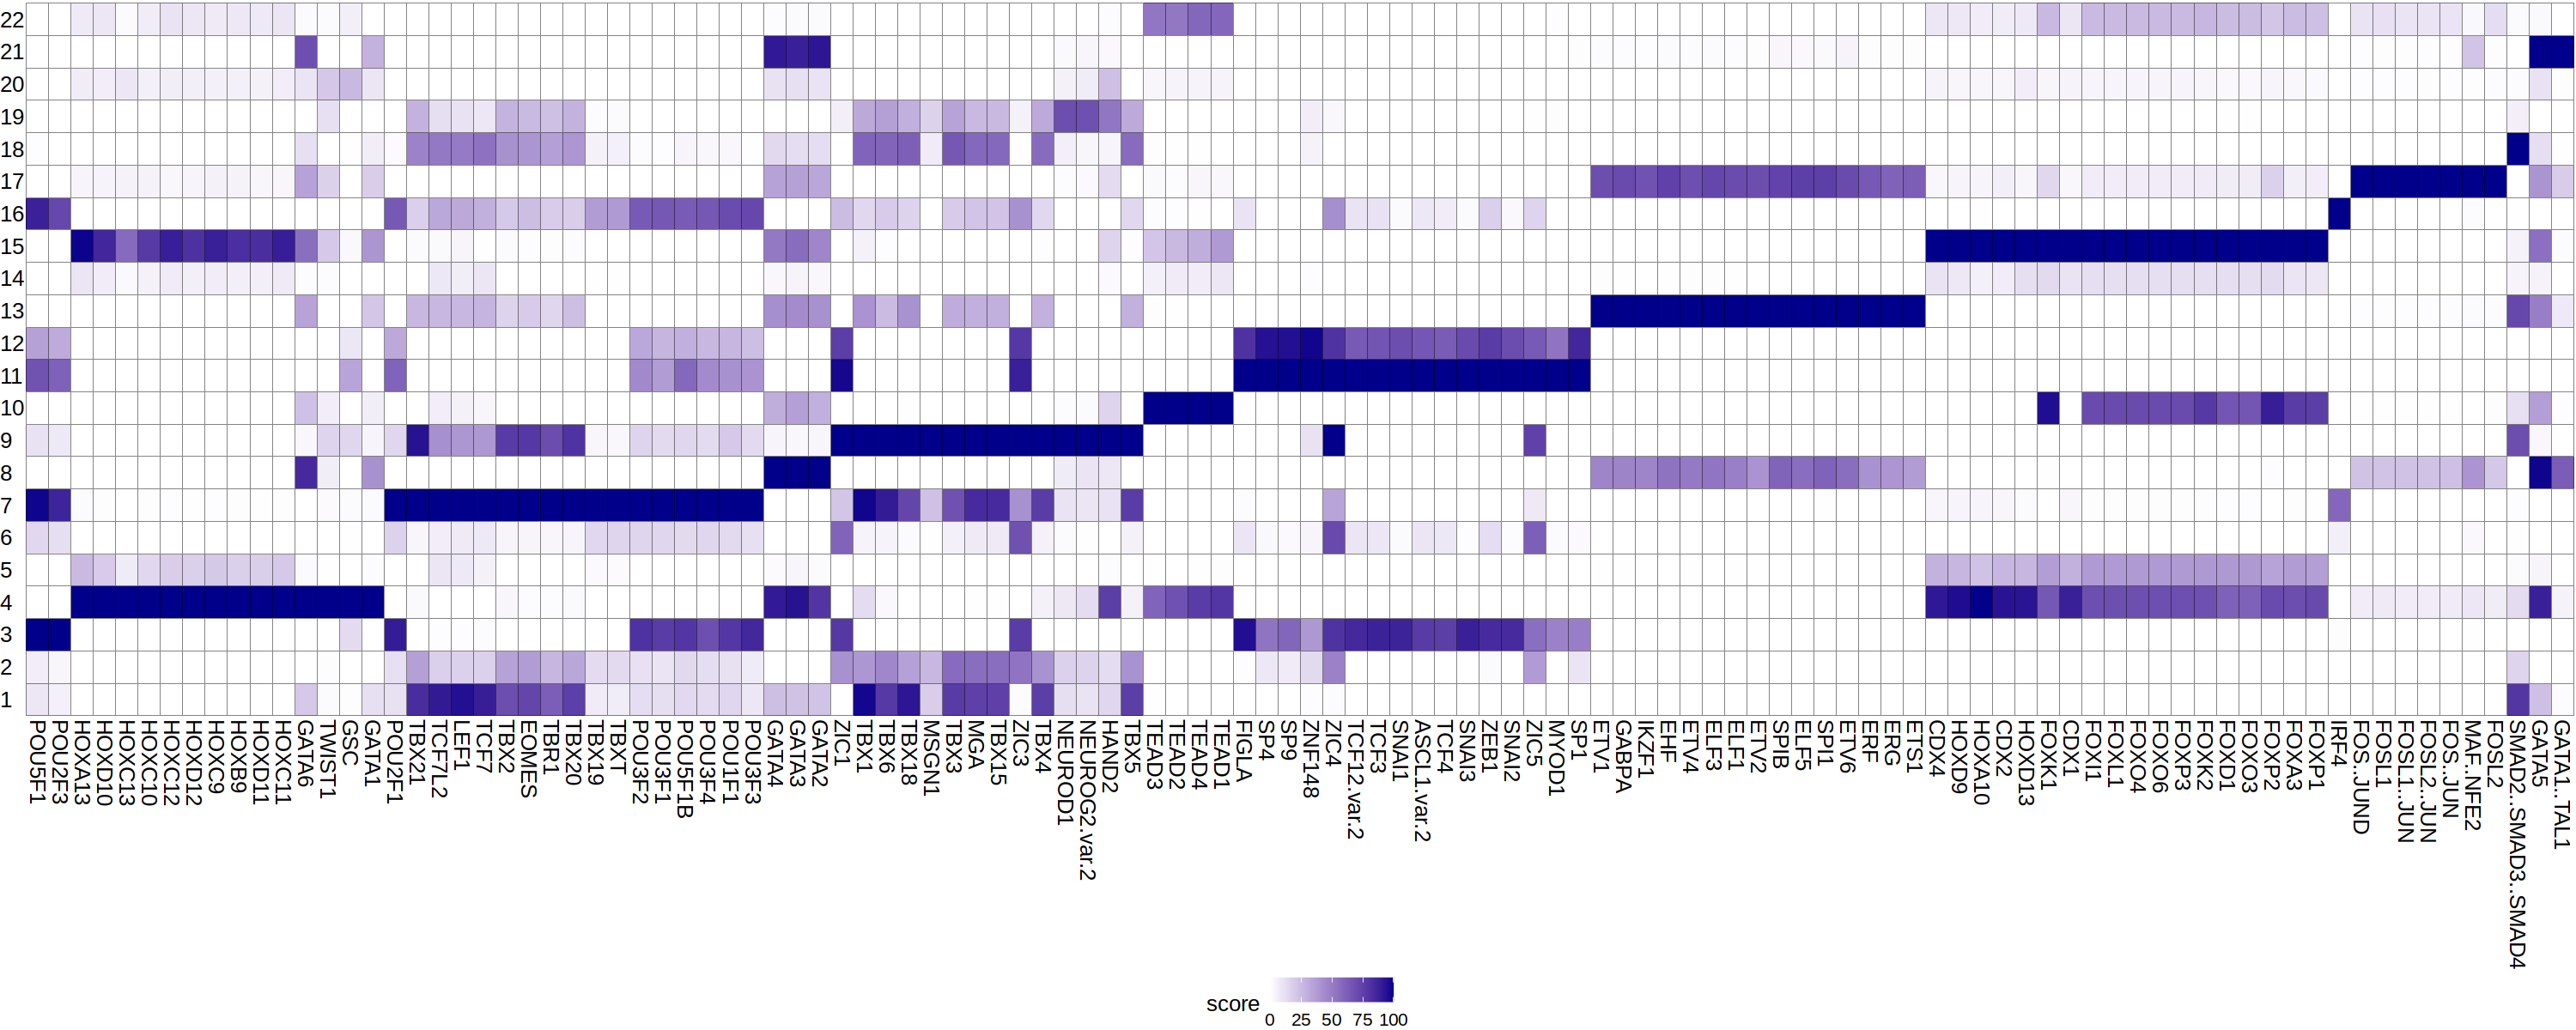

In [75]:
enrichMotifs <- suppressMessages(peakAnnoEnrichment(
    seMarker = out,
    ArchRProj = ArchRProject,
    peakAnnotation = "Motif_JASPAR2020",
    cutOff = "FDR <= 0.1 & Log2FC >= 0.5"
  ))

options(repr.plot.width=25, repr.plot.height=10)
plot_enr_heatmap(enrichMotifs, ntop = 15)  + 
        scale_fill_gradient(low='white', high='darkblue', name='score')